In [1]:
import os
import sys
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

# 6 thuật toán phân loại bắt buộc
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.dummy import DummyClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)

RANDOM_STATE = 42
TARGET = "Recommended IND"

plt.style.use('seaborn-v0_8-whitegrid')
print("Môi trường sẵn sàng cho E-Commerce System!")

Môi trường sẵn sàng cho E-Commerce System!


In [3]:
DATA_PATH = "Womens Clothing E-Commerce Reviews.csv"
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Không tìm thấy file {DATA_PATH}. Hãy kiểm tra lại thư mục làm việc.")

df = pd.read_csv(DATA_PATH)
print("Kích thước dữ liệu gốc:", df.shape)
print("\nThông tin kiểu dữ liệu:")
df.info()

print("\nKiểm tra giá trị khuyết thiếu ban đầu:")
print(df.isna().sum())

print("\nSố lượng bản ghi trùng lặp ban đầu:", df.duplicated().sum())
display(df.head())

Kích thước dữ liệu gốc: (23486, 11)

Thông tin kiểu dữ liệu:
<class 'pandas.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Unnamed: 0               23486 non-null  int64
 1   Clothing ID              23486 non-null  int64
 2   Age                      23486 non-null  int64
 3   Title                    19676 non-null  str  
 4   Review Text              22641 non-null  str  
 5   Rating                   23486 non-null  int64
 6   Recommended IND          23486 non-null  int64
 7   Positive Feedback Count  23486 non-null  int64
 8   Division Name            23472 non-null  str  
 9   Department Name          23472 non-null  str  
 10  Class Name               23472 non-null  str  
dtypes: int64(6), str(5)
memory usage: 2.0 MB

Kiểm tra giá trị khuyết thiếu ban đầu:
Unnamed: 0                    0
Clothing ID                   0
Age            

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [4]:
df_clean = df.copy()

# Xóa các cột định danh không mang giá trị quy nạp học máy
drop_cols = [c for c in ['Unnamed: 0', 'Clothing ID'] if c in df_clean.columns]
df_clean = df_clean.drop(columns=drop_cols)

# Loại bỏ các dòng trống biến mục tiêu
df_clean = df_clean.dropna(subset=[TARGET])
df_clean[TARGET] = df_clean[TARGET].astype(int)

# Điền giá trị rỗng cho văn bản
df_clean['Review Text'] = df_clean['Review Text'].fillna('')
df_clean['Title'] = df_clean['Title'].fillna('')

# Trích xuất đặc trưng mới từ văn bản
df_clean['Review_Length'] = df_clean['Review Text'].apply(lambda x: len(str(x)))
df_clean['Word_Count'] = df_clean['Review Text'].apply(lambda x: len(str(x).split()))

# Loại bỏ trùng lặp nếu có
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print("Kích thước dữ liệu sau khi làm sạch:", df_clean.shape)
display(df_clean.head())

Kích thước dữ liệu sau khi làm sạch: (23254, 11)


,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name,Review_Length,Word_Count
0,33,,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates,53,8
1,34,,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses,303,62
2,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses,500,98
3,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants,124,22
4,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses,192,36


C:\Users\The Hoang\AppData\Local\Temp\ipykernel_19696\768960739.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=df_clean[TARGET], palette='Set2')


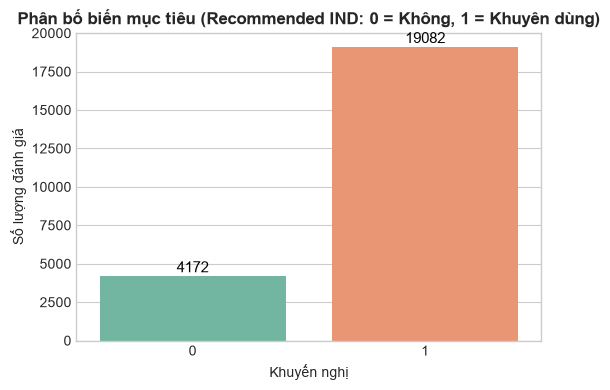

In [6]:
# 1. Phân bố biến mục tiêu (Recommended IND)
plt.figure(figsize=(6, 4))
ax = sns.countplot(x=df_clean[TARGET], palette='Set2')
plt.title('Phân bố biến mục tiêu (Recommended IND: 0 = Không, 1 = Khuyên dùng)', fontweight='bold')
plt.xlabel('Khuyến nghị')
plt.ylabel('Số lượng đánh giá')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 3), textcoords='offset points')
plt.savefig('ecomm_target_distribution.png', dpi=300)
plt.show()

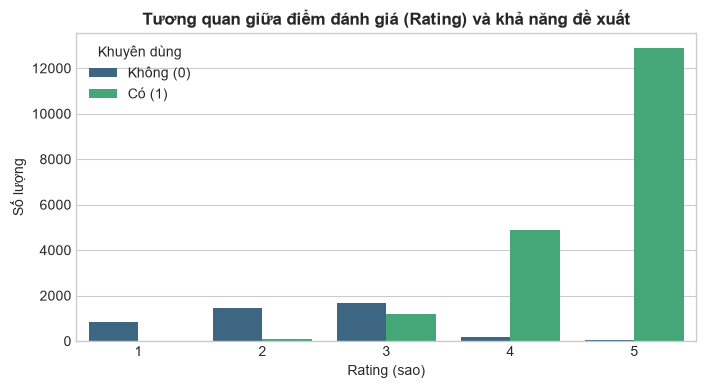

In [7]:
# 2. Quan hệ giữa Rating và mức độ đề xuất
plt.figure(figsize=(8, 4))
sns.countplot(data=df_clean, x='Rating', hue=TARGET, palette='viridis')
plt.title('Tương quan giữa điểm đánh giá (Rating) và khả năng đề xuất', fontweight='bold')
plt.xlabel('Rating (sao)')
plt.ylabel('Số lượng')
plt.legend(title='Khuyên dùng', labels=['Không (0)', 'Có (1)'])
plt.savefig('ecomm_rating_vs_recommended.png', dpi=300)
plt.show()

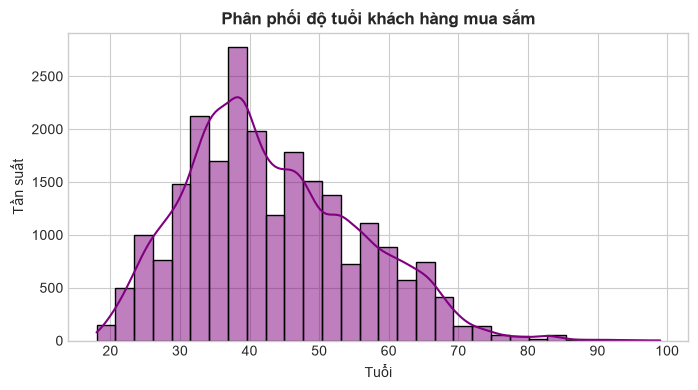

In [8]:
# 3. Phân bố độ tuổi khách hàng (Histogram & KDE)
plt.figure(figsize=(8, 4))
sns.histplot(df_clean['Age'], bins=30, kde=True, color='purple')
plt.title('Phân phối độ tuổi khách hàng mua sắm', fontweight='bold')
plt.xlabel('Tuổi')
plt.ylabel('Tần suất')
plt.savefig('ecomm_age_distribution.png', dpi=300)
plt.show()

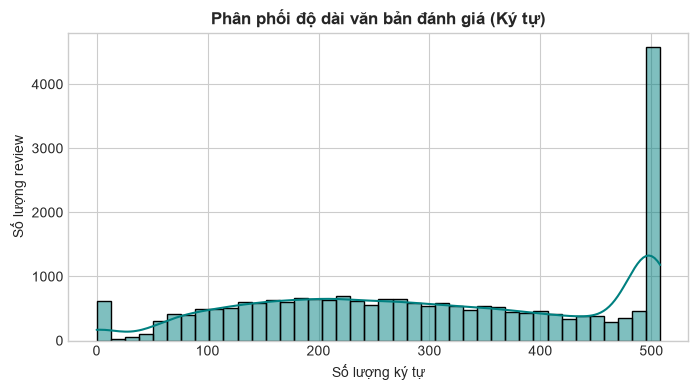

In [9]:
# 4. Phân phối độ dài đánh giá (Review Length)
plt.figure(figsize=(8, 4))
sns.histplot(df_clean['Review_Length'], bins=40, kde=True, color='teal')
plt.title('Phân phối độ dài văn bản đánh giá (Ký tự)', fontweight='bold')
plt.xlabel('Số lượng ký tự')
plt.ylabel('Số lượng review')
plt.savefig('ecomm_review_length_distribution.png', dpi=300)
plt.show()

C:\Users\The Hoang\AppData\Local\Temp\ipykernel_19696\4154886369.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, y='Department Name', order=df_clean['Department Name'].value_counts().index, palette='crest')


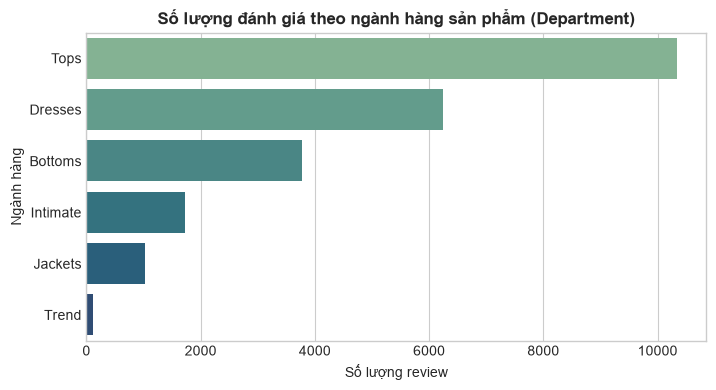

In [10]:
# 5. Phân bố theo nhóm sản phẩm (Department Name)
if 'Department Name' in df_clean.columns:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df_clean, y='Department Name', order=df_clean['Department Name'].value_counts().index, palette='crest')
    plt.title('Số lượng đánh giá theo ngành hàng sản phẩm (Department)', fontweight='bold')
    plt.xlabel('Số lượng review')
    plt.ylabel('Ngành hàng')
    plt.savefig('ecomm_department_distribution.png', dpi=300)
    plt.show()

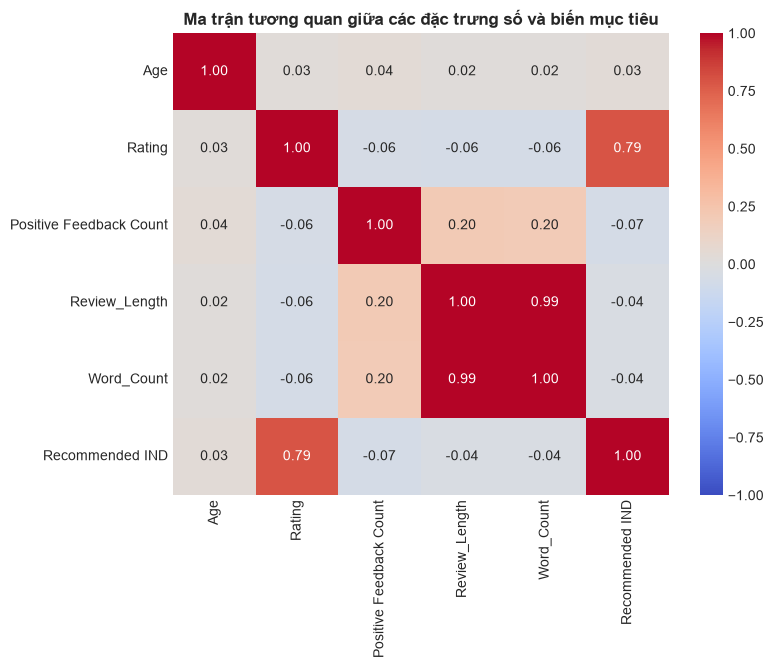

In [11]:
# 6. Ma trận tương quan đặc trưng số
plt.figure(figsize=(8, 6))
numeric_eda = ['Age', 'Rating', 'Positive Feedback Count', 'Review_Length', 'Word_Count', TARGET]
sns.heatmap(df_clean[numeric_eda].corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Ma trận tương quan giữa các đặc trưng số và biến mục tiêu', fontweight='bold')
plt.savefig('ecomm_correlation_matrix.png', dpi=300)
plt.show()

In [12]:
X = df_clean.drop(columns=[TARGET])
y = df_clean[TARGET]

# Chia 70% Train, 30% Tạm thời có bảo đảm phân tầng (stratify)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

# Chia 30% Tạm thời thành 15% Validation và 15% Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

print(f"Kích thước tập Train: {X_train.shape[0]} mẫu")
print(f"Kích thước tập Validation: {X_val.shape[0]} mẫu")
print(f"Kích thước tập Test: {X_test.shape[0]} mẫu")

Kích thước tập Train: 16277 mẫu
Kích thước tập Validation: 3488 mẫu
Kích thước tập Test: 3489 mẫu


In [15]:
from sklearn.preprocessing import MinMaxScaler

# Xác định các nhóm thuộc tính
num_cols = ['Age', 'Rating', 'Positive Feedback Count', 'Review_Length', 'Word_Count']
cat_cols = [c for c in ['Division Name', 'Department Name', 'Class Name'] if c in X.columns]
text_col = 'Review Text'

# Pipeline cho biến số: Dùng MinMaxScaler thay vì StandardScaler để dữ liệu luôn >= 0
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler())
])

# Pipeline cho biến phân loại
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Kết hợp cả biến bảng và văn bản TF-IDF (TF-IDF vốn đã luôn >= 0)
full_preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_cols),
        ('cat', cat_pipeline, cat_cols),
        ('text', TfidfVectorizer(max_features=2500, ngram_range=(1, 2), stop_words='english'), text_col)
    ]
)

# Fit pipeline trên tập Train
X_train_proc = full_preprocessor.fit_transform(X_train)
X_val_proc = full_preprocessor.transform(X_val)
X_test_proc = full_preprocessor.transform(X_test)

print("Kích thước ma trận đặc trưng sau tiền xử lý (Train):", X_train_proc.shape)

Kích thước ma trận đặc trưng sau tiền xử lý (Train): (16277, 2534)


In [16]:
# 1. Baseline Model
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train_proc, y_train)

# 2. Khai báo 6 mô hình
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=15, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=RANDOM_STATE),
    "Naive Bayes": MultinomialNB(),
    "Linear SVM": SVC(kernel='linear', probability=True, random_state=RANDOM_STATE)
}

# Đánh giá Baseline trên tập Validation
y_val_dummy = dummy.predict(X_val_proc)
eval_results = [{
    'Model': 'Baseline (Dummy)',
    'Accuracy': accuracy_score(y_val, y_val_dummy),
    'Precision': precision_score(y_val, y_val_dummy, zero_division=0),
    'Recall': recall_score(y_val, y_val_dummy, zero_division=0),
    'F1-score': f1_score(y_val, y_val_dummy, zero_division=0),
    'ROC-AUC': 0.5000
}]

fitted_models = {}
val_preds = {}
val_probas = {}

# Huấn luyện lần lượt
for name, clf in classifiers.items():
    print(f"Đang huấn luyện {name}...")
    clf.fit(X_train_proc, y_train)
    fitted_models[name] = clf
    
    y_pred = clf.predict(X_val_proc)
    val_preds[name] = y_pred
    
    # Dự đoán xác suất cho ROC-AUC
    if hasattr(clf, "predict_proba"):
        y_prob = clf.predict_proba(X_val_proc)[:, 1]
    else:
        y_prob = clf.decision_function(X_val_proc)
    val_probas[name] = y_prob
    
    eval_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_val, y_pred),
        'Precision': precision_score(y_val, y_pred, zero_division=0),
        'Recall': recall_score(y_val, y_pred, zero_division=0),
        'F1-score': f1_score(y_val, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_val, y_prob)
    })

eval_df = pd.DataFrame(eval_results)
eval_df = eval_df.sort_values(by='F1-score', ascending=False).reset_index(drop=True)
print("\n===== KẾT QUẢ SO SÁNH TRÊN TẬP VALIDATION =====")
display(eval_df.round(4))

Đang huấn luyện Logistic Regression...
Đang huấn luyện Decision Tree...
Đang huấn luyện Random Forest...
Đang huấn luyện Gradient Boosting...
Đang huấn luyện Naive Bayes...
Đang huấn luyện Linear SVM...


C:\Users\The Hoang\miniconda3\envs\ml\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(



===== KẾT QUẢ SO SÁNH TRÊN TẬP VALIDATION =====


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.9444,0.9603,0.9724,0.9663,0.9811
1,Linear SVM,0.9424,0.9638,0.9661,0.9649,0.9795
2,Gradient Boosting,0.9424,0.9812,0.9479,0.9643,0.9790
3,Decision Tree,0.9366,0.9853,0.9368,0.9604,0.9591
4,Naive Bayes,0.8787,0.8800,0.9867,0.9303,0.9376
5,Random Forest,0.8506,0.8472,0.9979,0.9164,0.9746
6,Baseline (Dummy),0.8205,0.8205,1.0000,0.9014,0.5000


C:\Users\The Hoang\AppData\Local\Temp\ipykernel_19696\1032089621.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=eval_df[eval_df['Model'] != 'Baseline (Dummy)'], x='F1-score', y='Model', palette='mako')


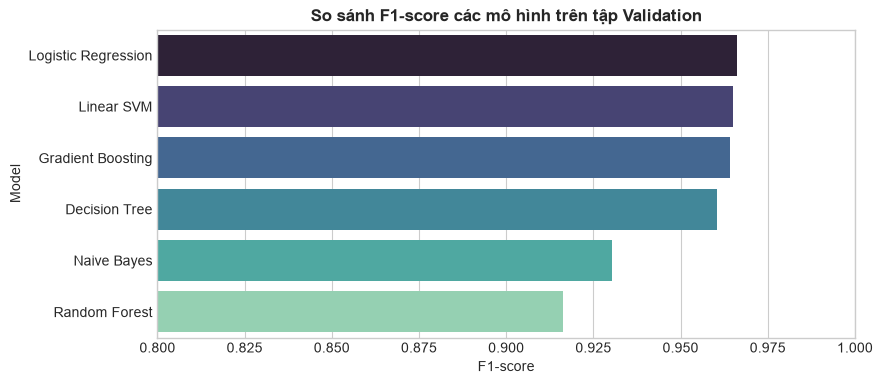

C:\Users\The Hoang\AppData\Local\Temp\ipykernel_19696\1032089621.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=eval_df[eval_df['Model'] != 'Baseline (Dummy)'], x='ROC-AUC', y='Model', palette='crest')


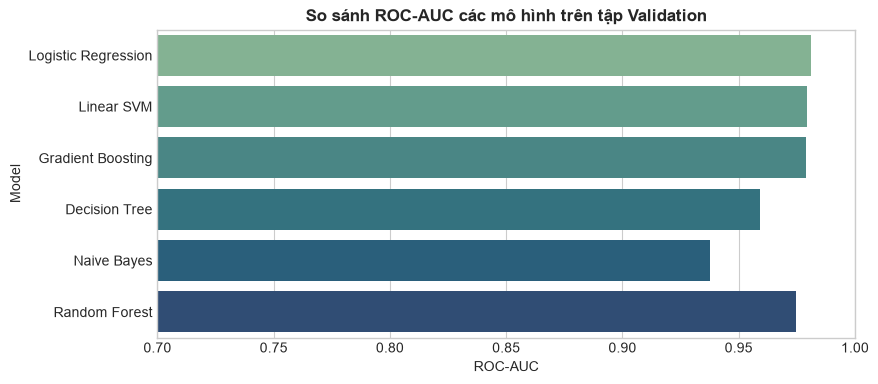

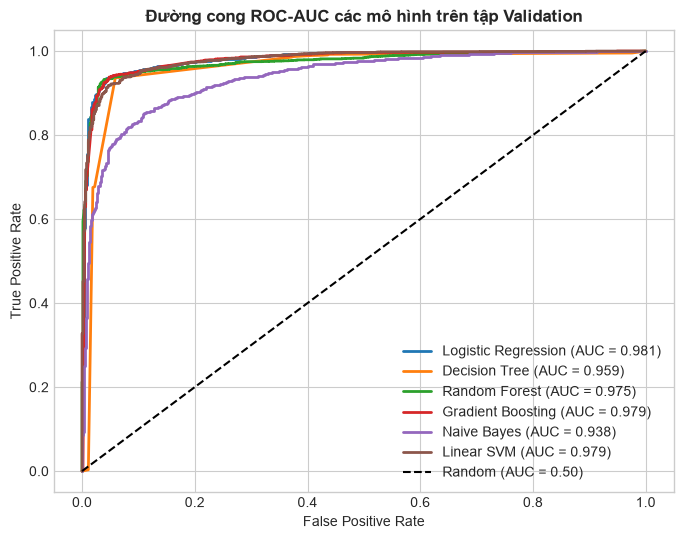

In [17]:
# 1. So sánh F1-score
plt.figure(figsize=(9, 4))
sns.barplot(data=eval_df[eval_df['Model'] != 'Baseline (Dummy)'], x='F1-score', y='Model', palette='mako')
plt.title('So sánh F1-score các mô hình trên tập Validation', fontweight='bold')
plt.xlim(0.8, 1.0)
plt.savefig('ecomm_f1_comparison.png', dpi=300)
plt.show()

# 2. So sánh ROC-AUC
plt.figure(figsize=(9, 4))
sns.barplot(data=eval_df[eval_df['Model'] != 'Baseline (Dummy)'], x='ROC-AUC', y='Model', palette='crest')
plt.title('So sánh ROC-AUC các mô hình trên tập Validation', fontweight='bold')
plt.xlim(0.7, 1.0)
plt.savefig('ecomm_auc_comparison.png', dpi=300)
plt.show()

# 3. Đường cong ROC trên tập Validation của 6 mô hình
plt.figure(figsize=(8, 6))
for name, y_prob in val_probas.items():
    fpr, tpr, _ = roc_curve(y_val, y_prob)
    auc_val = roc_auc_score(y_val, y_prob)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {auc_val:.3f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random (AUC = 0.50)')
plt.title('Đường cong ROC-AUC các mô hình trên tập Validation', fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.savefig('ecomm_roc_curves.png', dpi=300)
plt.show()

Mô hình được chọn là: Logistic Regression

===== ĐÁNH GIÁ TRÊN TẬP TEST ĐỘC LẬP =====
Accuracy: 0.9410
Precision: 0.9618
Recall: 0.9665
F1-score: 0.9641
ROC-AUC: 0.9788


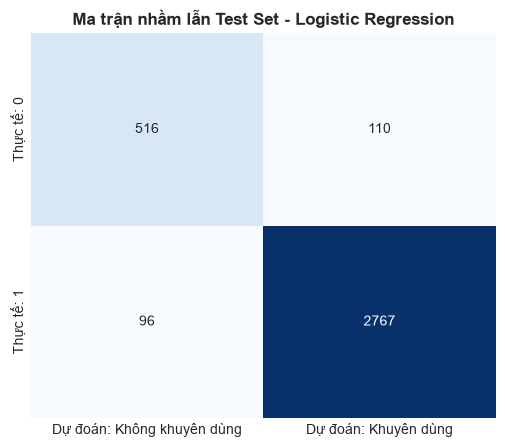

In [18]:
# Chọn mô hình có F1-score cao nhất (thường là Logistic Regression hoặc Linear SVM)
best_model_name = eval_df[eval_df['Model'] != 'Baseline (Dummy)'].iloc[0]['Model']
best_clf = fitted_models[best_model_name]
print(f"Mô hình được chọn là: {best_model_name}\n")

# Dự đoán trên Test Set
y_test_pred = best_clf.predict(X_test_proc)
y_test_prob = best_clf.predict_proba(X_test_proc)[:, 1] if hasattr(best_clf, "predict_proba") else best_clf.decision_function(X_test_proc)

test_metrics = {
    'Accuracy': accuracy_score(y_test, y_test_pred),
    'Precision': precision_score(y_test, y_test_pred),
    'Recall': recall_score(y_test, y_test_pred),
    'F1-score': f1_score(y_test, y_test_pred),
    'ROC-AUC': roc_auc_score(y_test, y_test_prob)
}

print("===== ĐÁNH GIÁ TRÊN TẬP TEST ĐỘC LẬP =====")
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}")

# Vẽ Ma trận nhầm lẫn (Confusion Matrix) trên tập Test
cm_test = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Dự đoán: Không khuyên dùng', 'Dự đoán: Khuyên dùng'],
            yticklabels=['Thực tế: 0', 'Thực tế: 1'])
plt.title(f'Ma trận nhầm lẫn Test Set - {best_model_name}', fontweight='bold')
plt.savefig('ecomm_confusion_matrix_test.png', dpi=300)
plt.show()

In [19]:
# Tạo Pipeline hoàn chỉnh bao gồm cả Preprocessor và Classifier
final_deployable_pipeline = Pipeline([
    ('preprocessor', full_preprocessor),
    ('classifier', best_clf)
])

# Lưu file model
MODEL_FILE = "best_ecommerce_model.pkl"
joblib.dump(final_deployable_pipeline, MODEL_FILE)
print(f"Đã đóng gói và lưu Pipeline thành công: {MODEL_FILE}")

# Smoke test kiểm chứng tải lại model
loaded_pipe = joblib.load(MODEL_FILE)
sample_test = X_test.iloc[[0]]
sample_pred = loaded_pipe.predict(sample_test)[0]
sample_prob = loaded_pipe.predict_proba(sample_test)[0]
print("Test suy luận độc lập:")
print(f"- Dự đoán nhãn: {sample_pred}")
print(f"- Xác suất: {sample_prob}")

Đã đóng gói và lưu Pipeline thành công: best_ecommerce_model.pkl
Test suy luận độc lập:
- Dự đoán nhãn: 1
- Xác suất: [0.00251464 0.99748536]
